import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned dataset
df = pd.read_pickle("../data/processed/clean_data.pkl")

In [4]:
# Checking the data before RFM
df[["CustomerID", "Invoice", "InvoiceDate", "Revenue"]].head()

,CustomerID,Invoice,InvoiceDate,Revenue
0,13085.0,489434,2009-12-01 07:45:00,83.4
1,13085.0,489434,2009-12-01 07:45:00,81.0
2,13085.0,489434,2009-12-01 07:45:00,81.0
3,13085.0,489434,2009-12-01 07:45:00,100.8
4,13085.0,489434,2009-12-01 07:45:00,30.0


In [5]:
# Finding the last transaction date
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [6]:
# Creating the snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

### Calculate Recency

In [7]:
# Calculating the last purchase date for each customer
last_purchase = df.groupby("CustomerID")["InvoiceDate"].max()
last_purchase.head()

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[ns]

In [8]:
recency = (snapshot_date - last_purchase).dt.days
recency.head()

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: InvoiceDate, dtype: int64

### Calculate Frequency

In [9]:
frequency = df.groupby("CustomerID")["Invoice"].nunique()
frequency.head()

CustomerID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64

### Calculate Monetary Value

In [10]:
monetary = df.groupby("CustomerID")["Revenue"].sum()
monetary.head()

CustomerID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: Revenue, dtype: float64

### Combine Recency, Frequency and Monetary

In [11]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


### Check the RFM dataset

In [12]:
print("RFM shape:", rfm.shape)

print("\nRFM table preview:")
print(rfm.head())

RFM shape: (5878, 3)

RFM table preview:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326         12  77556.46
12347.0           2          8   4921.53
12348.0          75          5   2019.40
12349.0          19          4   4428.69
12350.0         310          1    334.40


In [13]:
rfm.describe().round(1)

,Recency,Frequency,Monetary
count,5878.0,5878.0,5878.0
mean,201.3,6.3,2955.9
std,209.3,13.0,14440.9
min,1.0,1.0,3.0
25%,26.0,1.0,342.3
50%,96.0,3.0,867.7
75%,380.0,7.0,2248.3
max,739.0,398.0,580987.0


### Create Recency Score

In [14]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4, 3, 2, 1]
).astype(int)

### Create Frequency Score

In [16]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

### Create Monetary Score

In [17]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

### Check the scores

In [18]:
rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "R_Score",
    "F_Score",
    "M_Score"
]].head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,12,77556.46,2,4,4
12347.0,2,8,4921.53,4,4,4
12348.0,75,5,2019.40,3,3,3
12349.0,19,4,4428.69,4,3,4
12350.0,310,1,334.40,2,1,1
12351.0,375,1,300.93,2,1,1
12352.0,36,10,2849.84,3,4,4
12353.0,204,2,406.76,2,2,2
12354.0,232,1,1079.40,2,1,3


### Calculate the Total RFM Score

In [19]:
rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

### Create Customer Segments

In [20]:
def get_segment(score):
    if score >= 10:
        return "High Value"
    elif score >= 6:
        return "Medium Value"
    else:
        return "Low Value"

In [21]:
rfm["Segment"] = rfm["RFM_Total"].apply(get_segment)

### Check how many customers are in each segment

In [22]:
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

Segment
Medium Value    2402
High Value      1740
Low Value       1736
Name: count, dtype: int64


### Create a Segment Summary

In [27]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Recency", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum")
).round(1)

segment_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Segment,,,,,
High Value,1740,37.2,15.2,8056.4,14018171.7
Low Value,1736,415.4,1.3,292.6,507948.7
Medium Value,2402,165.5,3.5,1186.0,2848683.8


### Calculate Revenue Share

In [28]:
segment_summary["RevenueShare"] = (
    segment_summary["TotalRevenue"]
    / segment_summary["TotalRevenue"].sum()
    * 100
).round(1)

## Display the final summary

In [30]:
print("=== Segment Summary ===")
segment_summary

=== Segment Summary ===


,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,RevenueShare
Segment,,,,,,
High Value,1740,37.2,15.2,8056.4,14018171.7,80.7
Low Value,1736,415.4,1.3,292.6,507948.7,2.9
Medium Value,2402,165.5,3.5,1186.0,2848683.8,16.4


### Visualize Customer Segments

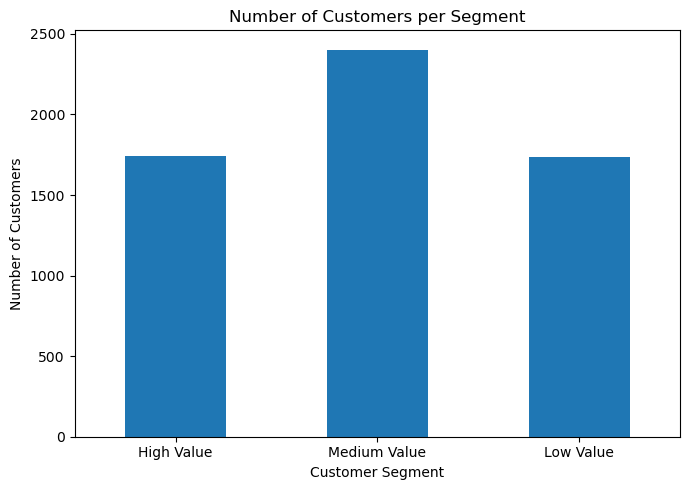

In [31]:
segment_order = ["High Value", "Medium Value", "Low Value"]

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reindex(segment_order)
)

segment_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Number of Customers per Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualize Revenue Share

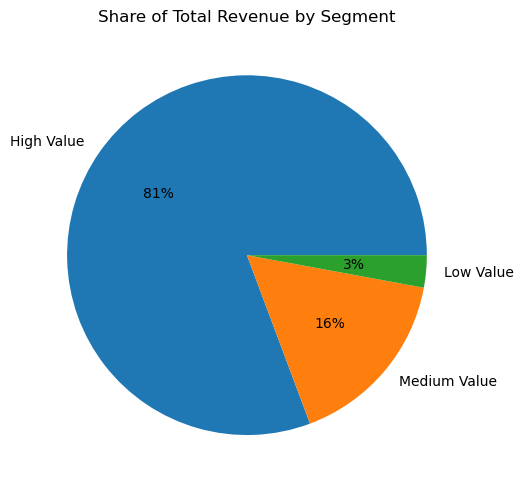

In [32]:
revenue_share = segment_summary["RevenueShare"].reindex(segment_order)

revenue_share.plot(
    kind="pie",
    figsize=(7, 5),
    autopct="%1.0f%%"
)

plt.title("Share of Total Revenue by Segment")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Save the RFM Dataset

In [33]:
rfm.to_pickle("../data/processed/rfm.pkl")